In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 경고 무시 설정
import warnings
warnings.filterwarnings(action='ignore')

# 한글 깨짐 방지
plt.rcParams['font.family'] = 'Malgun Gothic'
# 마이너스 부호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

## 건강기능식품 주구입처 분석

In [2]:
df = pd.read_csv('./건강기능식품_주_구입처_및_이용_이유.csv')
df.head()

,특성별(1),특성별(2),2019,2019.1,2019.2,2019.3,2019.4,2019.5,2019.6,2019.7,...,2024.11,2024.12,2024.13,2024.14,2024.15,2024.16,2024.17,2024.18,2024.19,2024.20
0,특성별(1),특성별(2),주 구입처,주 구입처,주 구입처,주 구입처,주 구입처,주 구입처,주 구입처,주 구입처,...,주 구입처,주 구입처 이용 이유,주 구입처 이용 이유,주 구입처 이용 이유,주 구입처 이용 이유,주 구입처 이용 이유,주 구입처 이용 이유,주 구입처 이용 이유,주 구입처 이용 이유,주 구입처 이용 이유
1,특성별(1),특성별(2),"동네 슈퍼마켓, 식자재마트",대기업에서 운영하는 슈퍼마켓,대형 할인점,백화점,드럭스토어·약국,통신판매,특정상표대리점,방문판매,...,해외 직구 사이트,우수한 품질의 제품을 살 수 있어서,가격이 더 저렴해서,이벤트/ 할인행사 등을 자주해서,유명하고 신뢰할만한 곳이라서,다양한 상품이 있어서,거리가 가깝거나 교통이 편해서,주변사람이 추천해서,자세한 설명을 들을 수 있어서,다른 곳에서는 원하는 상품을 살 수 없어서
2,전체,소계,2.0,7.0,27.2,6.5,20.1,18.1,15.3,3.4,...,1.8,17.8,19.1,14.4,12.8,16.4,5.3,6.0,7.7,0.5
3,거주지역별,수도권,2.2,9.3,29.8,7.1,16.5,19.4,11.9,3.4,...,2.4,16.0,18.7,14.4,11.7,15.9,6.5,6.8,9.6,0.3
4,NaN,충청권,1.9,6.7,14.3,6.8,27.9,13.8,25.8,2.7,...,1.4,14.3,25.9,16.9,9.1,16.0,4.4,5.4,7.4,0.8


In [3]:
import pandas as pd

# 1. 컬럼명 확인
print(df.columns)

# 2. '이용 이유'가 포함된 컬럼들 찾기
# (참고: CSV 구조상 '이용 이유' 혹은 구체적인 문구가 포함되어 있을 것입니다)
cols_to_drop = [c for c in df.columns if '이유' in c]

# 3. 해당 컬럼 삭제 (axis=1은 열 삭제를 의미합니다)
df_cleaned = df.drop(columns=cols_to_drop)

# 결과 확인
df_cleaned.head()

Index(['특성별(1)', '특성별(2)', '2019', '2019.1', '2019.2', '2019.3', '2019.4',
       '2019.5', '2019.6', '2019.7',
       ...
       '2024.11', '2024.12', '2024.13', '2024.14', '2024.15', '2024.16',
       '2024.17', '2024.18', '2024.19', '2024.20'],
      dtype='str', length=130)


,특성별(1),특성별(2),2019,2019.1,2019.2,2019.3,2019.4,2019.5,2019.6,2019.7,...,2024.11,2024.12,2024.13,2024.14,2024.15,2024.16,2024.17,2024.18,2024.19,2024.20
0,특성별(1),특성별(2),주 구입처,주 구입처,주 구입처,주 구입처,주 구입처,주 구입처,주 구입처,주 구입처,...,주 구입처,주 구입처 이용 이유,주 구입처 이용 이유,주 구입처 이용 이유,주 구입처 이용 이유,주 구입처 이용 이유,주 구입처 이용 이유,주 구입처 이용 이유,주 구입처 이용 이유,주 구입처 이용 이유
1,특성별(1),특성별(2),"동네 슈퍼마켓, 식자재마트",대기업에서 운영하는 슈퍼마켓,대형 할인점,백화점,드럭스토어·약국,통신판매,특정상표대리점,방문판매,...,해외 직구 사이트,우수한 품질의 제품을 살 수 있어서,가격이 더 저렴해서,이벤트/ 할인행사 등을 자주해서,유명하고 신뢰할만한 곳이라서,다양한 상품이 있어서,거리가 가깝거나 교통이 편해서,주변사람이 추천해서,자세한 설명을 들을 수 있어서,다른 곳에서는 원하는 상품을 살 수 없어서
2,전체,소계,2.0,7.0,27.2,6.5,20.1,18.1,15.3,3.4,...,1.8,17.8,19.1,14.4,12.8,16.4,5.3,6.0,7.7,0.5
3,거주지역별,수도권,2.2,9.3,29.8,7.1,16.5,19.4,11.9,3.4,...,2.4,16.0,18.7,14.4,11.7,15.9,6.5,6.8,9.6,0.3
4,NaN,충청권,1.9,6.7,14.3,6.8,27.9,13.8,25.8,2.7,...,1.4,14.3,25.9,16.9,9.1,16.0,4.4,5.4,7.4,0.8


In [5]:
import pandas as pd

# 1. 데이터 로드 (첫 2개 행을 헤더로 읽어 다중 헤더 처리)
df = pd.read_csv('건강기능식품_주_구입처_및_이용_이유.csv', header=[0, 1])

# 2. '가구주연령별' 데이터만 추출
# 특성별(1)이 가구주연령별인 행만 필터링합니다.
age_df = df[df[('특성별(1)', '특성별(1)')] == '가구주연령별']

# 3. '이용 이유' 컬럼 제외하기
# 레벨 1 헤더(구입처/이유)에서 '이유'가 들어가지 않은 컬럼만 선택합니다.
cols_to_keep = [col for col in age_df.columns if '이유' not in col[1]]
age_purchase_df = age_df[cols_to_keep]

# 4. 보기 좋게 정리 (불필요한 인덱스 제거 및 출력)
age_purchase_df = age_purchase_df.reset_index(drop=True)
age_purchase_df

특성별(1) 특성별(2)  2019                                                  \
   특성별(1) 특성별(2) 주 구입처 주 구입처.1 주 구입처.2 주 구입처.3 주 구입처.4 주 구입처.5 주 구입처.6   
0  가구주연령별    20대   0.7     5.5    22.1     9.8    19.3    23.7    13.8   

           ...    2024                                                  \
  주 구입처.7  ... 주 구입처.2 주 구입처.3 주 구입처.4 주 구입처.5 주 구입처.6 주 구입처.7 주 구입처.8   
0     5.0  ...     8.1     0.7     0.9     1.7    62.9     6.2     5.4   

                             
  주 구입처.9 주 구입처.10 주 구입처.11  
0     3.6      0.0      6.9  

[1 rows x 73 columns]

In [9]:
import pandas as pd

# 1. 데이터 불러오기 (첫 두 행을 헤더로 설정)
# 파일 경로는 본인의 환경에 맞게 수정해주세요.
df = pd.read_csv('건강기능식품_주_구입처_및_이용_이유.csv', header=[0, 1])

# 2. '특성별(1)' 컬럼에서 '가구주연령별'인 행만 필터링
# 결측치(NaN)를 처리하기 위해 fillna를 사용하여 범위를 확장합니다.
df[('특성별(1)', '특성별(1)')] = df[('특성별(1)', '특성별(1)')].ffill()
age_all_df = df[df[('특성별(1)', '특성별(1)')] == '가구주연령별']

# 3. '이용 이유'가 들어간 컬럼 제외하고 '주 구입처'만 남기기
# 컬럼의 두 번째 레벨(Level 1)에 '이유'라는 단어가 없는 것만 골라냅니다.
final_cols = [col for col in age_all_df.columns if '이유' not in col[1]]
age_purchase_df = age_all_df[final_cols]

# 4. 인덱스 재설정 및 결과 출력
age_purchase_df = age_purchase_df.reset_index(drop=True)
display(age_purchase_df)

특성별(1)  특성별(2)  2019                                                  \
   특성별(1)  특성별(2) 주 구입처 주 구입처.1 주 구입처.2 주 구입처.3 주 구입처.4 주 구입처.5 주 구입처.6   
0  가구주연령별     20대   0.7     5.5    22.1     9.8    19.3    23.7    13.8   
1  가구주연령별     30대   1.9     6.2    30.0     6.0    20.4    21.3    12.4   
2  가구주연령별     40대   2.2     8.1    24.9     6.2    20.0    18.9    15.6   
3  가구주연령별     50대   2.3     7.9    28.3     5.9    19.2    12.0    18.6   
4  가구주연령별  60대 이상   3.5     7.0    26.8     5.2    24.7     4.0    23.4   

           ...    2024                                                  \
  주 구입처.7  ... 주 구입처.2 주 구입처.3 주 구입처.4 주 구입처.5 주 구입처.6 주 구입처.7 주 구입처.8   
0     5.0  ...     8.1     0.7     0.9     1.7    62.9     6.2     5.4   
1     1.7  ...    20.7     0.6     3.9     0.1    41.2     9.6     9.2   
2     3.9  ...    25.9     0.9     2.9     0.0    35.3    11.4    11.5   
3     4.6  ...    24.1     0.4     2.2     0.1    25.8    18.3    10.7   
4     4.9  ...    23.2     1.4     3.9     0.3    15.0    18.7    15.6   

                             
  주 구입처.9 주 구입처.10 주 구입처.11  
0     3.6      0.0      6.9  
1     5.8      0.9      4.7  
2     3.0      0.9      2.0  
3     7.5      2.3      1.6  
4    11.4      2.2      0.6  

[5 rows x 73 columns]

In [11]:
import pandas as pd

# 1. 데이터 로드 (멀티 헤더 설정)
df = pd.read_csv('건강기능식품_주_구입처_및_이용_이유.csv', header=[0, 1])

# 2. '특성별(1)'의 빈칸을 채워줍니다 (병합된 셀 처리)
# 이렇게 하면 '20대'부터 '60대 이상'까지 모두 '가구주연령별'이라는 값을 갖게 됩니다.
df[('특성별(1)', '특성별(1)')] = df[('특성별(1)', '특성별(1)')].ffill()

# 3. '가구주연령별' 행들만 추출
age_df = df[df[('특성별(1)', '특성별(1)')] == '가구주연령별']

# 4. '이용 이유' 컬럼 제외하고 '주 구입처'만 필터링
# 컬럼명의 두 번째 레벨(Level 1)에 '이유'가 포함되지 않은 컬럼만 선택
purchase_cols = [col for col in age_df.columns if '이유' not in col[1]]
age_purchase_df = age_df[purchase_cols]

# 5. 결과 확인 (20대~60대 이상까지 총 5개 행이 출력됩니다)
age_purchase_df = age_purchase_df.reset_index(drop=True)
age_purchase_df

특성별(1)  특성별(2)  2019                                                  \
   특성별(1)  특성별(2) 주 구입처 주 구입처.1 주 구입처.2 주 구입처.3 주 구입처.4 주 구입처.5 주 구입처.6   
0  가구주연령별     20대   0.7     5.5    22.1     9.8    19.3    23.7    13.8   
1  가구주연령별     30대   1.9     6.2    30.0     6.0    20.4    21.3    12.4   
2  가구주연령별     40대   2.2     8.1    24.9     6.2    20.0    18.9    15.6   
3  가구주연령별     50대   2.3     7.9    28.3     5.9    19.2    12.0    18.6   
4  가구주연령별  60대 이상   3.5     7.0    26.8     5.2    24.7     4.0    23.4   

           ...    2024                                                  \
  주 구입처.7  ... 주 구입처.2 주 구입처.3 주 구입처.4 주 구입처.5 주 구입처.6 주 구입처.7 주 구입처.8   
0     5.0  ...     8.1     0.7     0.9     1.7    62.9     6.2     5.4   
1     1.7  ...    20.7     0.6     3.9     0.1    41.2     9.6     9.2   
2     3.9  ...    25.9     0.9     2.9     0.0    35.3    11.4    11.5   
3     4.6  ...    24.1     0.4     2.2     0.1    25.8    18.3    10.7   
4     4.9  ...    23.2     1.4     3.9     0.3    15.0    18.7    15.6   

                             
  주 구입처.9 주 구입처.10 주 구입처.11  
0     3.6      0.0      6.9  
1     5.8      0.9      4.7  
2     3.0      0.9      2.0  
3     7.5      2.3      1.6  
4    11.4      2.2      0.6  

[5 rows x 73 columns]

In [13]:
import pandas as pd

# 1. 0번(연도)과 2번(세부 구입처) 헤더를 조합하여 읽기
# 1번 헤더(주 구입처/이용 이유 구분)는 일단 포함하되 나중에 필터링용으로 씁니다.
df = pd.read_csv('건강기능식품_주_구입처_및_이용_이유.csv', header=[0, 1, 2])

# 2. '특성별(1)'의 병합된 셀(NaN)을 채워 모든 연령대 행을 식별 가능하게 함
df[('특성별(1)', '특성별(1)', '특성별(1)')] = df[('특성별(1)', '특성별(1)', '특성별(1)')].ffill()

# 3. '가구주연령별'에 해당하는 모든 행(20대~60대 이상) 추출
age_df = df[df[('특성별(1)', '특성별(1)', '특성별(1)')] == '가구주연령별']

# 4. '이용 이유' 컬럼은 과감히 삭제하고 '주 구입처'만 남기기
# 레벨 1(중간 헤더)이 '주 구입처'인 컬럼만 선택합니다.
purchase_only_cols = [col for col in age_df.columns if '주 구입처' in col[1] or '특성별' in col[0]]
final_df = age_df[purchase_only_cols]

# 5. 보기 편하게 멀티헤더 정리 (연도와 세부항목만 남기기)
# '주 구입처'라는 중간 라벨을 삭제하여 [2022, 대형마트] 형태로 만듭니다.
final_df.columns = [f"{col[0]}_{col[2]}" if "20" in col[0] else col[2] for col in final_df.columns]

# 6. 인덱스 정리 및 출력
final_df = final_df.reset_index(drop=True)
final_df

,특성별(1),특성별(2),"2019_동네 슈퍼마켓, 식자재마트",2019_대기업에서 운영하는 슈퍼마켓,2019_대형 할인점,2019_백화점,2019_드럭스토어·약국,2019_통신판매,2019_특정상표대리점,2019_방문판매,...,2024_해외 직구 사이트,2024_우수한 품질의 제품을 살 수 있어서,2024_가격이 더 저렴해서,2024_이벤트/ 할인행사 등을 자주해서,2024_유명하고 신뢰할만한 곳이라서,2024_다양한 상품이 있어서,2024_거리가 가깝거나 교통이 편해서,2024_주변사람이 추천해서,2024_자세한 설명을 들을 수 있어서,2024_다른 곳에서는 원하는 상품을 살 수 없어서
0,가구주연령별,20대,0.7,5.5,22.1,9.8,19.3,23.7,13.8,5.0,...,6.9,15.3,21.1,16.0,16.6,16.1,1.5,8.6,2.5,2.3
1,가구주연령별,30대,1.9,6.2,30.0,6.0,20.4,21.3,12.4,1.7,...,4.7,20.5,18.8,15.7,11.4,17.2,4.4,5.6,6.0,0.2
2,가구주연령별,40대,2.2,8.1,24.9,6.2,20.0,18.9,15.6,3.9,...,2.0,14.5,21.0,14.7,10.4,20.4,4.9,6.4,7.3,0.4
3,가구주연령별,50대,2.3,7.9,28.3,5.9,19.2,12.0,18.6,4.6,...,1.6,18.3,19.4,15.1,12.7,15.5,5.9,5.8,6.8,0.5
4,가구주연령별,60대 이상,3.5,7.0,26.8,5.2,24.7,4.0,23.4,4.9,...,0.6,18.4,17.9,13.3,14.3,14.7,5.5,6.0,9.4,0.5


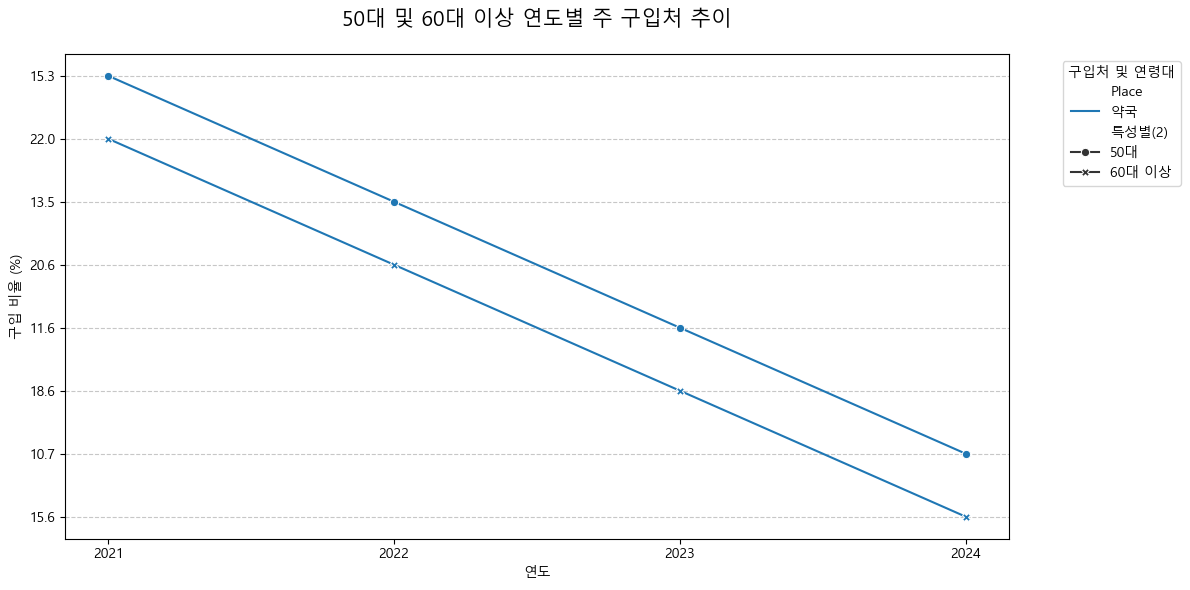

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 50대와 60대 이상 데이터만 필터링 (위에서 만든 final_df 활용)
target_ages = ['50대', '60대 이상']
analysis_df = final_df[final_df['특성별(2)'].isin(target_ages)]

# 2. 시각화를 위해 데이터 구조 변경 (Wide -> Long format)
# 연도_장소 형태의 컬럼을 분리합니다.
plot_data = analysis_df.melt(id_vars=['특성별(2)'], var_name='Year_Place', value_name='Ratio')
plot_data['Year'] = plot_data['Year_Place'].str.split('_').str[0]
plot_data['Place'] = plot_data['Year_Place'].str.split('_').str[1]

# 3. 주요 구입처만 선택 (데이터가 너무 많으면 복잡하므로 상위 5개 위주)
top_places = ['인터넷쇼핑몰', '약국', 'TV홈쇼핑', '대형마트', '인적판매(방문판매 등)']
plot_data = plot_data[plot_data['Place'].isin(top_places)]

# 4. 그래프 그리기
plt.figure(figsize=(12, 6))
sns.lineplot(data=plot_data, x='Year', y='Ratio', hue='Place', style='특성별(2)', markers=True, dashes=False)

plt.title('50대 및 60대 이상 연도별 주 구입처 추이', fontsize=15, pad=20)
plt.ylabel('구입 비율 (%)')
plt.xlabel('연도')
plt.legend(title='구입처 및 연령대', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

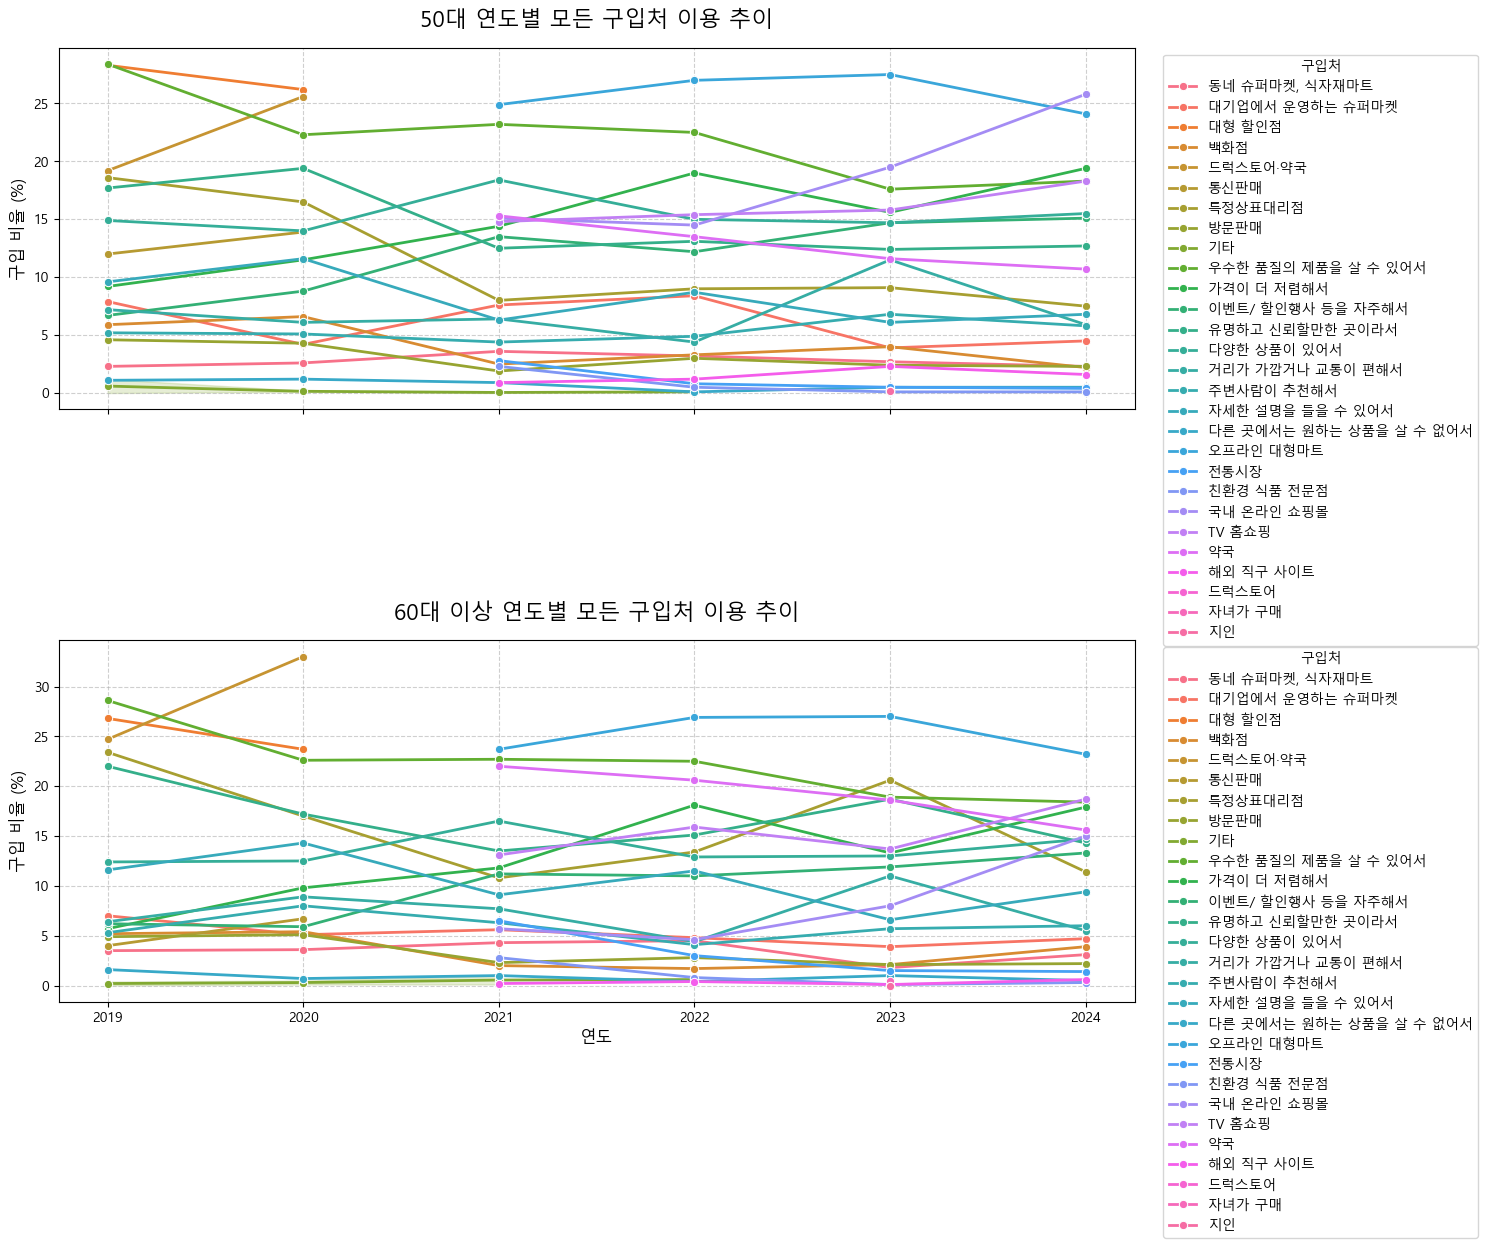

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 50대와 60대 이상 데이터 필터링
target_ages = ['50대', '60대 이상']
analysis_df = final_df[final_df['특성별(2)'].isin(target_ages)]

# 2. 데이터 구조 재구성 (Long Format)
plot_data = analysis_df.melt(id_vars=['특성별(2)'], var_name='Year_Place', value_name='Ratio')
plot_data['Year'] = plot_data['Year_Place'].str.split('_').str[0]
plot_data['Place'] = plot_data['Year_Place'].str.split('_').str[1]

# 비율 데이터 숫자형 변환 (혹시 모를 문자열 포함 대비)
plot_data['Ratio'] = pd.to_numeric(plot_data['Ratio'], errors='coerce')

# 3. 그래프 그리기 (50대와 60대 이상을 나누어 시각화)
fig, axes = plt.subplots(2, 1, figsize=(15, 12), sharex=True)

for i, age in enumerate(target_ages):
    curr_data = plot_data[plot_data['특성별(2)'] == age]
    
    # 모든 구입처에 대해 선 그래프 생성
    sns.lineplot(ax=axes[i], data=curr_data, x='Year', y='Ratio', hue='Place', 
                 marker='o', linewidth=2)
    
    axes[i].set_title(f'{age} 연도별 모든 구입처 이용 추이', fontsize=16, pad=15)
    axes[i].set_ylabel('구입 비율 (%)', fontsize=12)
    axes[i].legend(title='구입처', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)
    axes[i].grid(True, linestyle='--', alpha=0.6)

plt.xlabel('연도', fontsize=12)
plt.tight_layout()
plt.show()

In [18]:
import pandas as pd

# 1. 3개 층의 헤더를 모두 불러오기
df = pd.read_csv('건강기능식품_주_구입처_및_이용_이유.csv', header=[0, 1, 2])

# 2. '특성별(1)' 병합 셀 채우기 (20대~60대 이상 전체 행 인식용)
df[('특성별(1)', '특성별(1)', '특성별(1)')] = df[('특성별(1)', '특성별(1)', '특성별(1)')].ffill()

# 3. '가구주연령별' 행들만 추출 (20대, 30대, 40대, 50대, 60대 이상)
age_df = df[df[('특성별(1)', '특성별(1)', '특성별(1)')] == '가구주연령별'].copy()

# 4. '이용 이유'가 포함된 컬럼 삭제 (Level 1 헤더 기준 필터링)
# 중간 헤더(Level 1)가 '주 구입처'이거나 특성 정보인 컬럼만 유지합니다.
cols_to_keep = [col for col in age_df.columns if '이유' not in col[1]]
age_purchase_df = age_df[cols_to_keep]

# 5. 중간 헤더(Level 1) 삭제 및 컬럼명 정리
# [연도(Level 0), 구입처(Level 2)] 조합으로 컬럼명을 변경합니다.
new_columns = []
for col in age_purchase_df.columns:
    if '20' in col[0]: # 연도 정보가 있는 경우
        new_columns.append(f"{col[0]}_{col[2]}")
    else: # 특성별(1), 특성별(2) 등 기본 정보인 경우
        new_columns.append(col[2])

age_purchase_df.columns = new_columns

# 6. 인덱스 재설정 및 결과 확인
final_df = age_purchase_df.reset_index(drop=True)
final_df

,특성별(1),특성별(2),"2019_동네 슈퍼마켓, 식자재마트",2019_대기업에서 운영하는 슈퍼마켓,2019_대형 할인점,2019_백화점,2019_드럭스토어·약국,2019_통신판매,2019_특정상표대리점,2019_방문판매,...,2024_오프라인 대형마트,2024_전통시장,2024_백화점,2024_친환경 식품 전문점,2024_국내 온라인 쇼핑몰,2024_TV 홈쇼핑,2024_약국,2024_특정상표대리점,2024_방문판매,2024_해외 직구 사이트
0,가구주연령별,20대,0.7,5.5,22.1,9.8,19.3,23.7,13.8,5.0,...,8.1,0.7,0.9,1.7,62.9,6.2,5.4,3.6,0.0,6.9
1,가구주연령별,30대,1.9,6.2,30.0,6.0,20.4,21.3,12.4,1.7,...,20.7,0.6,3.9,0.1,41.2,9.6,9.2,5.8,0.9,4.7
2,가구주연령별,40대,2.2,8.1,24.9,6.2,20.0,18.9,15.6,3.9,...,25.9,0.9,2.9,0.0,35.3,11.4,11.5,3.0,0.9,2.0
3,가구주연령별,50대,2.3,7.9,28.3,5.9,19.2,12.0,18.6,4.6,...,24.1,0.4,2.2,0.1,25.8,18.3,10.7,7.5,2.3,1.6
4,가구주연령별,60대 이상,3.5,7.0,26.8,5.2,24.7,4.0,23.4,4.9,...,23.2,1.4,3.9,0.3,15.0,18.7,15.6,11.4,2.2,0.6


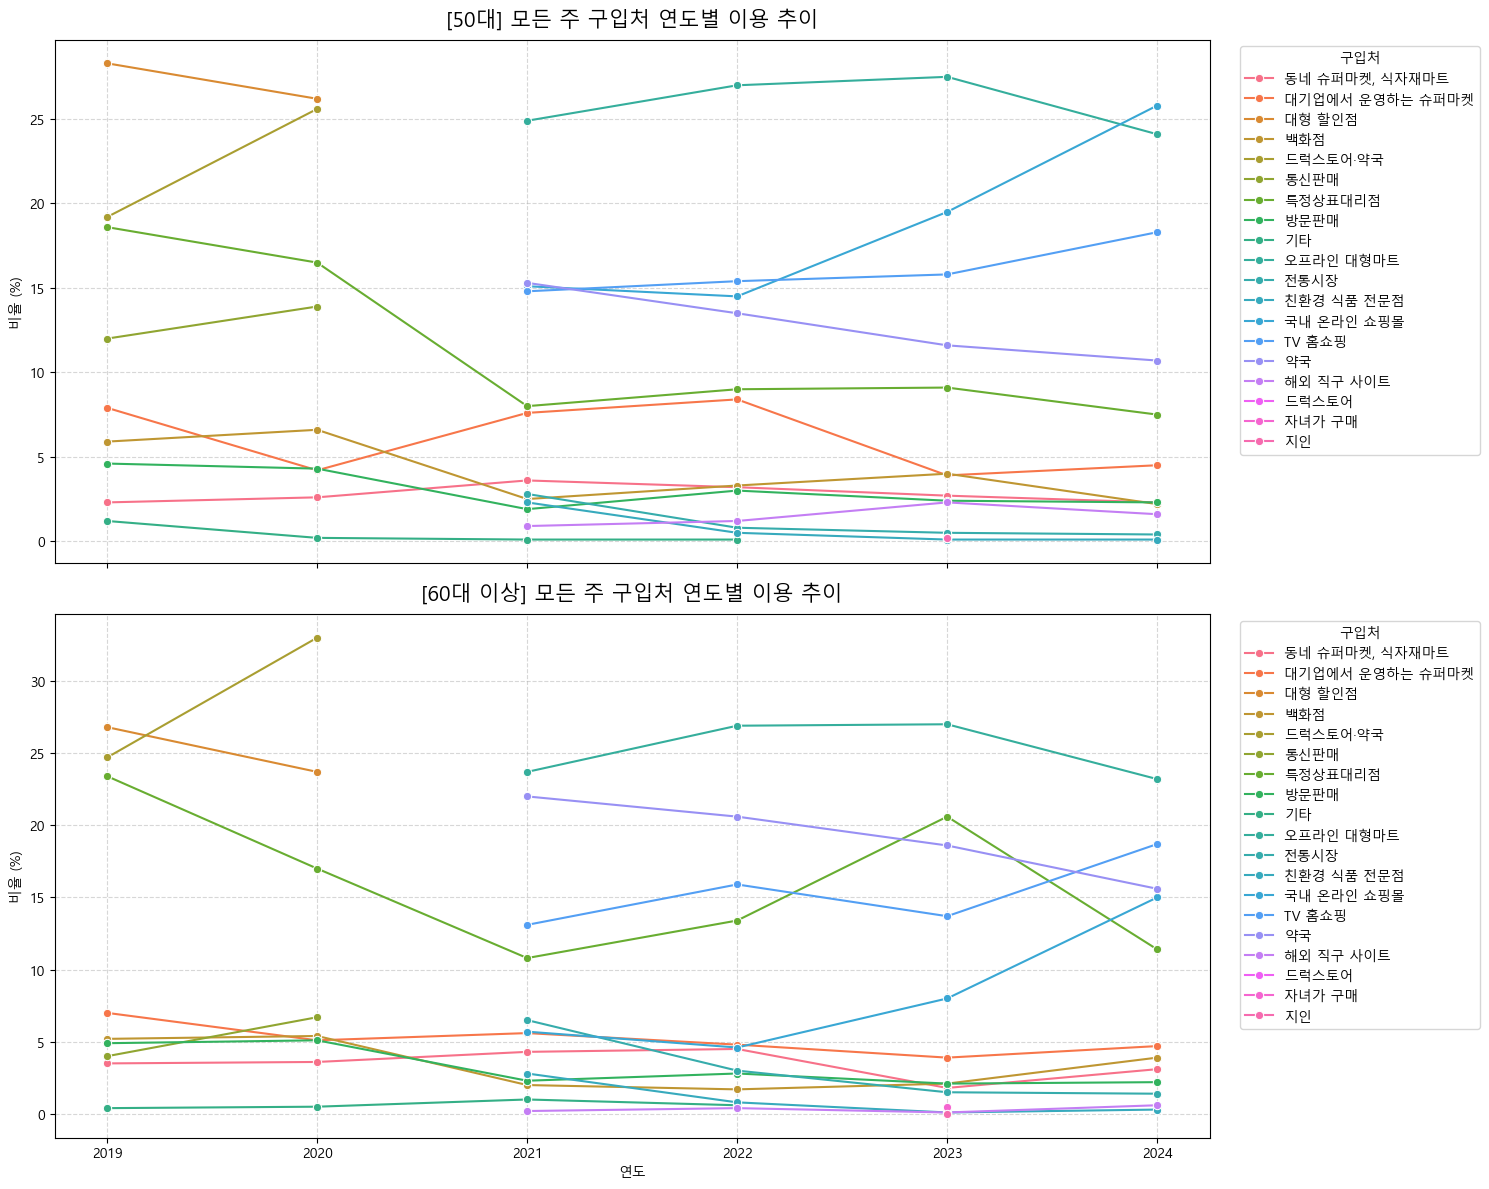

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# 50대와 60대 이상 데이터 필터링
target_df = final_df[final_df['특성별(2)'].isin(['50대', '60대 이상'])]

# 데이터 재구성 (시각화용 Long format)
plot_data = target_df.melt(id_vars=['특성별(1)', '특성별(2)'], var_name='Year_Place', value_name='Ratio')
plot_data['Year'] = plot_data['Year_Place'].str.split('_').str[0]
plot_data['Place'] = plot_data['Year_Place'].str.split('_').str[1]
plot_data['Ratio'] = pd.to_numeric(plot_data['Ratio'], errors='coerce')

# 그래프 그리기
target_ages = ['50대', '60대 이상']
fig, axes = plt.subplots(2, 1, figsize=(15, 12), sharex=True)

for i, age in enumerate(target_ages):
    curr_age_data = plot_data[plot_data['특성별(2)'] == age]
    sns.lineplot(ax=axes[i], data=curr_age_data, x='Year', y='Ratio', hue='Place', marker='o')
    
    axes[i].set_title(f'[{age}] 모든 주 구입처 연도별 이용 추이', fontsize=15, pad=10)
    axes[i].set_ylabel('비율 (%)')
    axes[i].legend(title='구입처', bbox_to_anchor=(1.02, 1), loc='upper left')
    axes[i].grid(True, linestyle='--', alpha=0.5)

plt.xlabel('연도')
plt.tight_layout()
plt.show()

## 건강기능식품 매출 변화 추이